# Use of the module

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# import modules of KGsolver
from KGsolver import RiccatiModel
import KGsolver as kg
from KGsolver.plotting import plot_potential

# 
import pandas as pd


plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"

# to save the data to csv
import pathlib

## Exponential Hyperbolic Tangent potential (alpha potential)

### a=-5, b=1, c=1

Sugestion to improve plots, change the number of Energy steps, **nE**, if the plot has peaks you can decrease of increase **nE** ultil the plot looks good, this is just to help KGSolver to solve the ODEs better. 

In [24]:
def suavizar_coeficiente(E, datos, E_quiebre, ancho, valor_objetivo, E_limite_caida=12.6):
    """
    E: Energía (Etilde)
    datos: El array de R o T original
    E_quiebre: Punto donde empieza la meseta (ej. 10.7)
    ancho: Suavizado de la transición (ej. 0.15)
    valor_objetivo: 1.0 para Reflexión, 0.0 para Transmisión
    E_limite_caida: Punto donde el algoritmo original debe retomar el control
    """
    # Factor de peso (Sigmoide)
    peso = 1.0 / (1.0 + np.exp(-(E - E_quiebre) / ancho))
    
    # Mezclamos los datos originales con el valor ideal (meseta)
    datos_suaves = (1 - peso) * datos + peso * valor_objetivo
    
    # Restauramos los datos originales después de la meseta (caida final)
    indices_finales = E > E_limite_caida
    datos_suaves[indices_finales] = datos[indices_finales]
    
    return datos_suaves


In [3]:
V, VL, VR, label = kg.expTanhPotential(a=-5,b=1, c= 1)
model1 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=8000)

E_mod1,R_mod1,T_mod1 = model1.compute_RT_spectrum(E_min=-7, E_max=4, nE=1000)


In [8]:
# save data to csv
path_data = pathlib.Path('ExpTanh-data')
path_data.mkdir(parents=True, exist_ok=True)
data = pd.DataFrame({'Energy (E)': E_mod1, 'Reflectivity (R)': R_mod1, 'Transmittance (T)': T_mod1})
data.to_csv(path_data / 'exptanh-fig1.csv', index=False)

**Shifted plot, this is the correct plot**

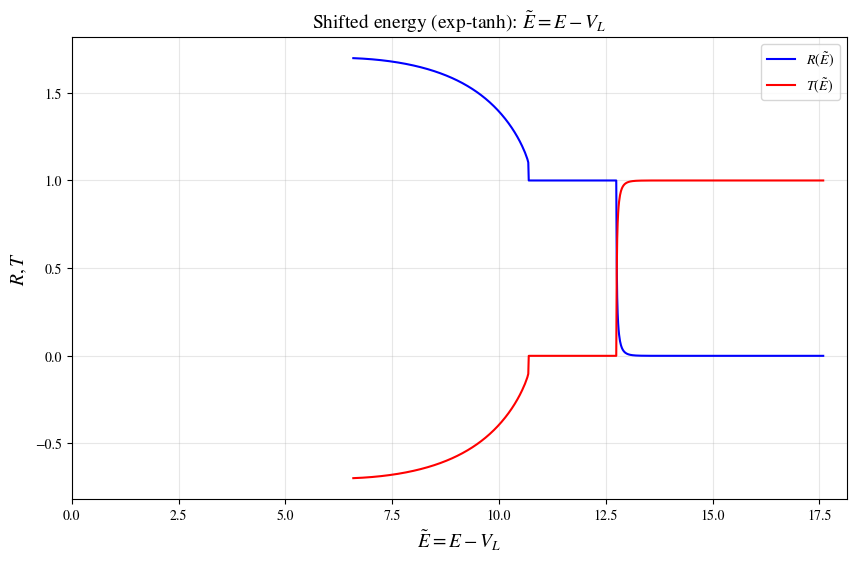

exp-tanh: V_L=-13.5914, V_R=-1.8394, m=1
Raw superradiant window (step approx): (V_L+m, V_R-m)=(-12.5914, -2.8394)
Shifted window in Etilde: (m, (V_R-V_L)-m)=(1, 10.752)


In [10]:
# Shifted-energy plot: E_tilde = E - V_L (left asymptotic plateau)
Etilde_mod1 = E_mod1 - model1.VL

plt.figure(figsize=(10,6))
plt.plot(Etilde_mod1, R_mod1, color="b", label=r"$R(\tilde E)$")
plt.plot(Etilde_mod1, T_mod1, color="r", label=r"$T(\tilde E)$")
plt.xlabel(r"$\tilde E = E - V_L$", fontsize=14)
plt.ylabel(r"$R, T$", fontsize=14)
plt.title(r"Shifted energy (exp-tanh): $\tilde E = E - V_L$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(left=0)
plt.show()

print(f"exp-tanh: V_L={model1.VL:.6g}, V_R={model1.VR:.6g}, m={model1.m:.6g}")
print(f"Raw superradiant window (step approx): (V_L+m, V_R-m)=({model1.VL+model1.m:.6g}, {model1.VR-model1.m:.6g})")
print(f"Shifted window in Etilde: (m, (V_R-V_L)-m)=({model1.m:.6g}, {(model1.VR-model1.VL)-model1.m:.6g})")


In [25]:
# smooth the R curve with the sigmoid factor
# 2. DEFINIMOS EL PUNTO DE TRANSICIÓN (Donde está el quiebre)
E_quiebre = 10.71 

# 3. PARÁMETRO DE SUAVIZADO
# 0.1 es sutil, 0.2 es más redondeado. Prueba con 0.15.
ancho = 0.025
R_smooth1 = suavizar_coeficiente(Etilde_mod1, R_mod1, E_quiebre, ancho, valor_objetivo=1.0)

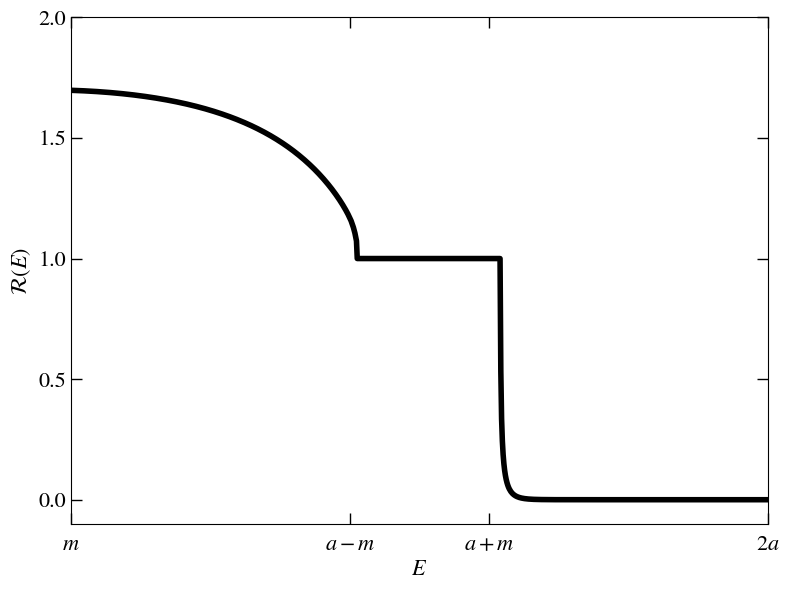

In [89]:
m = np.min(Etilde_mod1)
a = 5
Emax = np.max(Etilde_mod1)

plt.figure(figsize=(8, 6))
plt.plot(Etilde_mod1, R_smooth1, color="black", linestyle="-", linewidth=4, label=r"$\mathcal{R}(E)$")
# plt.plot(E_mod1, T_mod1, color="r", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")

plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{R}(E)$", fontsize=16)

# More uniform tick spacing in [m, Emax] using combinations of a and m
xtick_pos = [m, a+m -1, a +m+1, 2*a+m]
xtick_lbl = [r"$m$", r"$a-m$", r"$a+m$", r"$2a$"]
plt.xticks(xtick_pos, xtick_lbl, fontsize=13)

plt.xlim(np.min(Etilde_mod1), np.max(Etilde_mod1)-1)
plt.ylim(-0.1, 2)  
plt.yticks(np.arange(0, 2.01, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)
plt.tick_params(axis='x', pad=8)
plt.tight_layout()
plt.savefig(path_data / "R(E)-expTanh-c1.png", dpi=300)
plt.show()

In [27]:
# smooth T curve with the same sigmoid factor
T_smooth1 = suavizar_coeficiente(Etilde_mod1, T_mod1, E_quiebre, ancho, valor_objetivo=0.0)

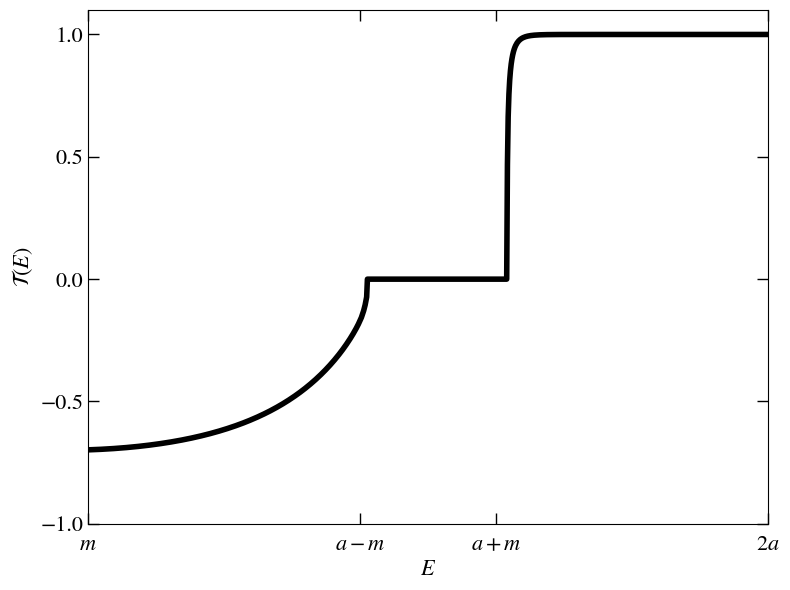

In [86]:
m = np.min(Etilde_mod1)
a = 5
Emax = np.max(Etilde_mod1)

plt.figure(figsize=(8, 6))
plt.plot(Etilde_mod1, T_smooth1, color="black", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")
# plt.plot(E_mod1, T_mod1, color="r", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")

plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{T}(E)$", fontsize=16)

# More uniform tick spacing in [m, Emax] using combinations of a and m
xtick_pos = [m, a +m -1, a +m +1, 2*a +m]
xtick_lbl = [r"$m$", r"$a-m$", r"$a+m$", r"$2a$"]
plt.xticks(xtick_pos, xtick_lbl, fontsize=13)

plt.xlim(np.min(Etilde_mod1), np.max(Etilde_mod1)-1)
plt.ylim(-1, 1.1)
plt.yticks(np.arange(-1, 1.1, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)
plt.tick_params(axis='x', pad=8)

plt.tight_layout()
plt.savefig(data_path / "T(E)-expTanh-c1.png", dpi=300)
plt.show()

### a=-5, b=1, c=20

In [29]:
V, VL, VR, label = kg.expTanhPotential(a=-5,b=1, c= 20)
model2 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=8000)

E_mod2,R_mod2,T_mod2 = model2.compute_RT_spectrum(E_min=-7, E_max=4, nE=600)

In [30]:
# save data to csv
data_path = pathlib.Path('ExpTanh-data')
data_path.mkdir(parents=True, exist_ok=True)
data2 = pd.DataFrame({'Energy (E)': E_mod2, 'Reflectivity (R)': R_mod2, 'Transmissivity (T)': T_mod2})
data2.to_csv(data_path / 'ExpTanh_fig2.csv', index=False)


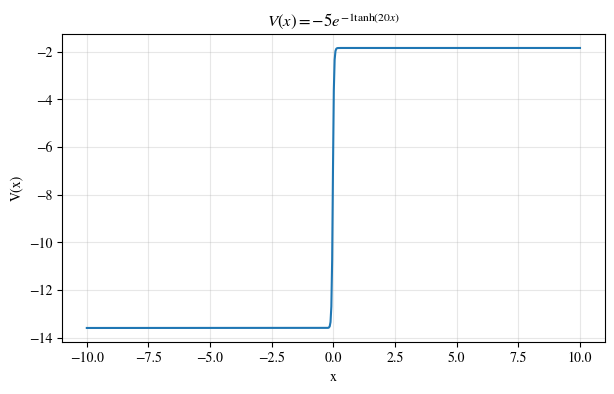

In [31]:
# potential
plot_potential(model2)

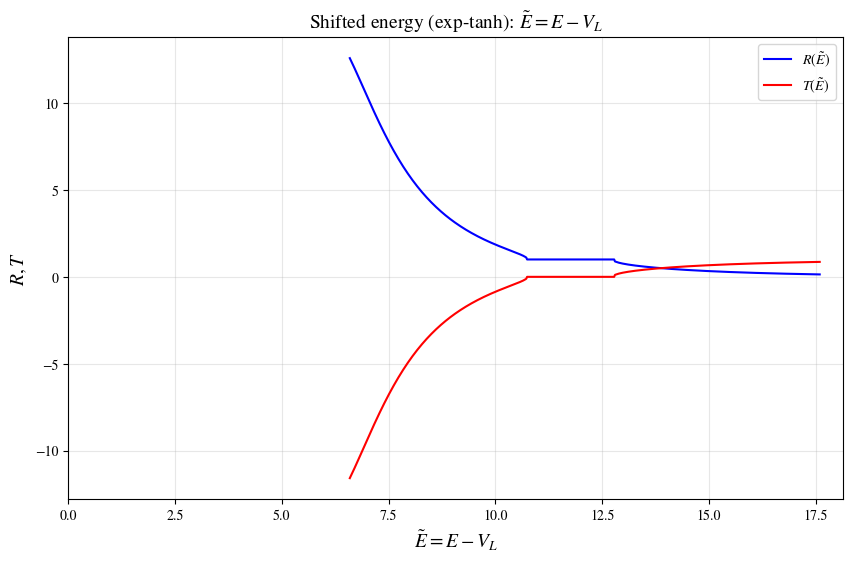

exp-tanh: V_L=-13.5914, V_R=-1.8394, m=1
Raw superradiant window (step approx): (V_L+m, V_R-m)=(-12.5914, -2.8394)
Shifted window in Etilde: (m, (V_R-V_L)-m)=(1, 10.752)


In [32]:
# Shifted-energy plot: E_tilde = E - V_L (left asymptotic plateau)
Etilde_mod2 = E_mod2 - model2.VL

plt.figure(figsize=(10,6))
plt.plot(Etilde_mod2, R_mod2, color="b", label=r"$R(\tilde E)$")
plt.plot(Etilde_mod2, T_mod2, color="r", label=r"$T(\tilde E)$")
plt.xlabel(r"$\tilde E = E - V_L$", fontsize=14)
plt.ylabel(r"$R, T$", fontsize=14)
plt.title(r"Shifted energy (exp-tanh): $\tilde E = E - V_L$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(left=0)
plt.show()

print(f"exp-tanh: V_L={model2.VL:.6g}, V_R={model2.VR:.6g}, m={model2.m:.6g}")
print(f"Raw superradiant window (step approx): (V_L+m, V_R-m)=({model2.VL+model2.m:.6g}, {model2.VR-model2.m:.6g})")
print(f"Shifted window in Etilde: (m, (V_R-V_L)-m)=({model2.m:.6g}, {(model2.VR-model2.VL)-model2.m:.6g})")

In [33]:
# smooth data for R and T
E_quiebre2 = 10.71
ancho2 = 0.025
R_smooth2 = suavizar_coeficiente(Etilde_mod2, R_mod2, E_quiebre2, ancho2, valor_objetivo=1.0)
T_smooth2 = suavizar_coeficiente(Etilde_mod2, T_mod2, E_quiebre2, ancho2, valor_objetivo=0.0)

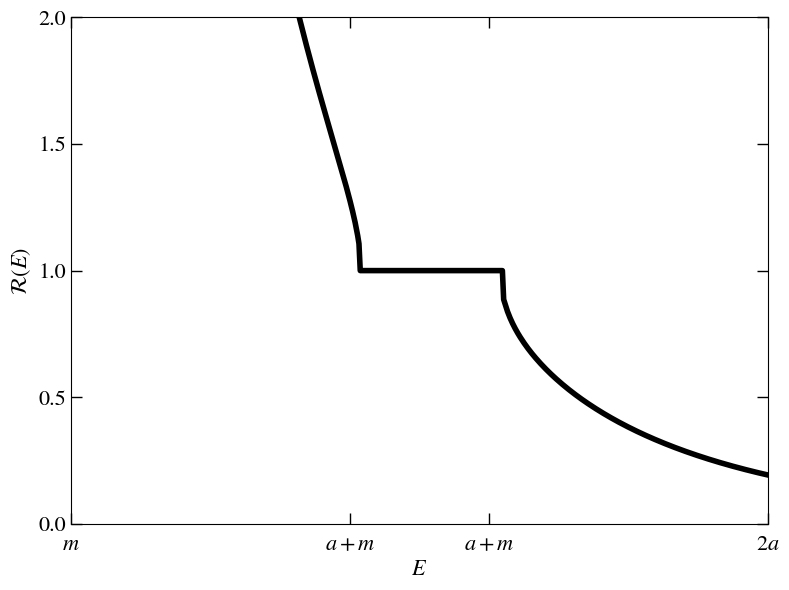

In [87]:
m = np.min(Etilde_mod2)
a = 5
Emax = np.max(Etilde_mod2)

plt.figure(figsize=(8, 6))
plt.plot(Etilde_mod2, R_mod2, color="black", linestyle="-", linewidth=4, label=r"$\mathcal{R}(E)$")
# plt.plot(E_mod2, T_mod2, color="r", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")

plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{R}(E)$", fontsize=16)

# More uniform tick spacing in [m, Emax] using combinations of a and m
xtick_pos = [m, a + m-1,a + m+1, 2* a+m]
xtick_lbl = [r"$m$", r"$a+m$", r"$a+m$", r"$2a$"]
plt.xticks(xtick_pos, xtick_lbl, fontsize=13)

plt.xlim(np.min(Etilde_mod2), np.max(Etilde_mod2)-1)
plt.ylim(0, 2)
plt.yticks(np.arange(0, 2.01, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)
plt.tick_params(axis='x', pad=8)

plt.tight_layout()
plt.savefig(data_path / "R(E)-expTanh-c20.png", dpi=300)
plt.show()

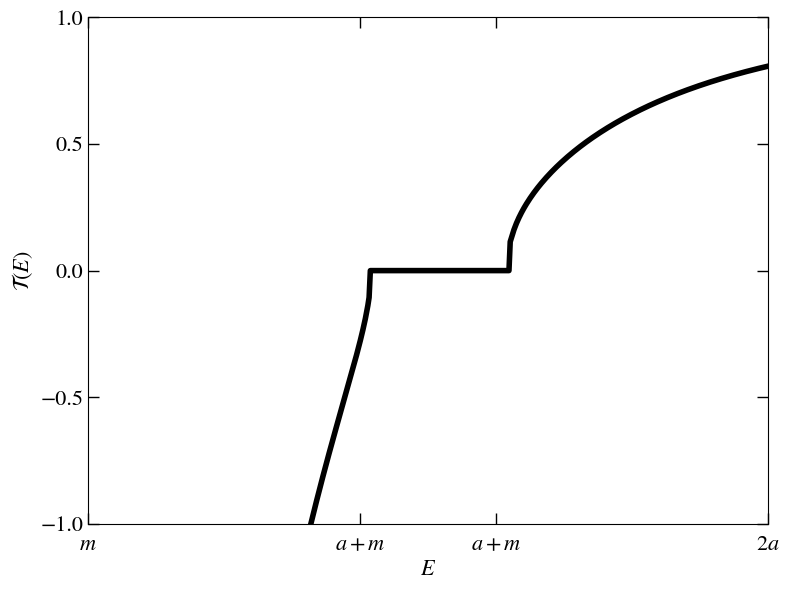

In [88]:
m = np.min(Etilde_mod2)
a = 5
Emax = np.max(Etilde_mod2)

plt.figure(figsize=(8, 6))
plt.plot(Etilde_mod2, T_mod2, color="black", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")
# plt.plot(E_mod2, T_mod2, color="r", linestyle="-", linewidth=4, label=r"$\mathcal{T}(E)$")

plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{T}(E)$", fontsize=16)

# More uniform tick spacing in [m, Emax] using combinations of a and m
xtick_pos = [m, a + m-1, a + m+1, 2 * a + m]
xtick_lbl = [r"$m$", r"$a+m$", r"$a+m$", r"$2a$"]
plt.xticks(xtick_pos, xtick_lbl, fontsize=13)

plt.xlim(np.min(Etilde_mod2), np.max(Etilde_mod2)-1)
plt.ylim(-1, 1.0)
plt.yticks(np.arange(-1, 1.01, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)
plt.tick_params(axis='x', pad=8)

plt.tight_layout()
plt.savefig(data_path / "T(E)-expTanh-c20.png", dpi=300)
plt.show()

## Hyperbolic Tangent Potential

### Figure 1

In [61]:
V, VL, VR, label = kg.TanhPotential(a=5,b=1)
model2_tanh = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)

E_mod2_tanh,R_mod2_tanh,T_mod2_tanh = model2_tanh.compute_RT_spectrum(E_min=0.1, E_max=10, nE=100)

In [62]:
# save data to csv
path_data = pathlib.Path('Tanh-data')
path_data.mkdir(parents=True, exist_ok=True)
data_tanh = pd.DataFrame({'Energy (E)': E_mod2_tanh, 'Reflectivity (R)': R_mod2_tanh, 'Transmittance (T)': T_mod2_tanh})
data_tanh.to_csv(path_data / 'tanh-fig1.csv', index=False)

In [63]:
# analytic results for tanh potential
data_T1  = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/T1_tanh.dat",delimiter= "\t"))
data_R1 = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/R1_tanh.dat",delimiter= "\t"))
data_T  = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/T_tanh.dat",delimiter= "\t"))
data_R = np.array(pd.read_csv("/home/angeldavid/Desktop/9th-semester/RQM/RelativisticQuantumMechanics/Analytic-data/Tanh/R_tanh.dat",delimiter= "\t"))

In [64]:
fullT = np.concatenate((data_T1[:,1], data_T[:,1]))
fullR = np.concatenate((data_R1[:,1], data_R[:,1]))
fullET = np.concatenate((data_T1[:,0], data_T[:,0]))
fullER = np.concatenate((data_R1[:,0], data_R[:,0]))

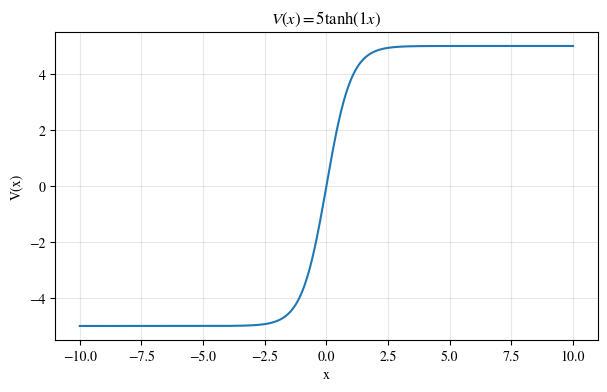

In [169]:
plot_potential(model2)

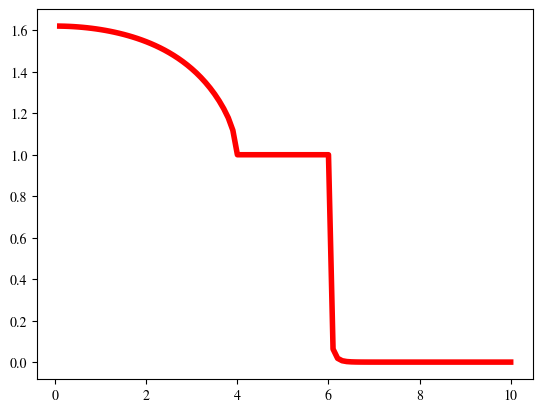

In [76]:
plt.plot(E_mod2_tanh, R_mod2_tanh, color="r", linestyle="-", linewidth=4, label=r"$\mathcal{R}(E)$")

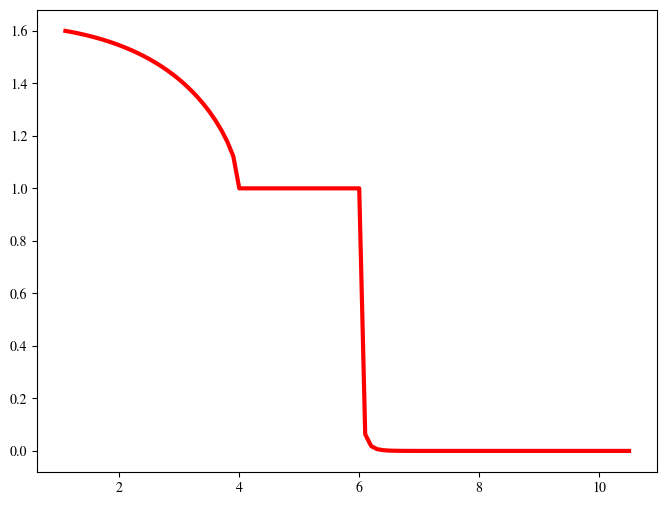

In [65]:
plt.figure(figsize=(8,6))
plt.plot(fullER, fullR, color="r", linestyle="-", linewidth=3, label=r"Analytic $R(E)$")
#plt.plot(E_mod2, R_mod2, color="b", linestyle="--", label=r"$R(E)$")
plt.show()

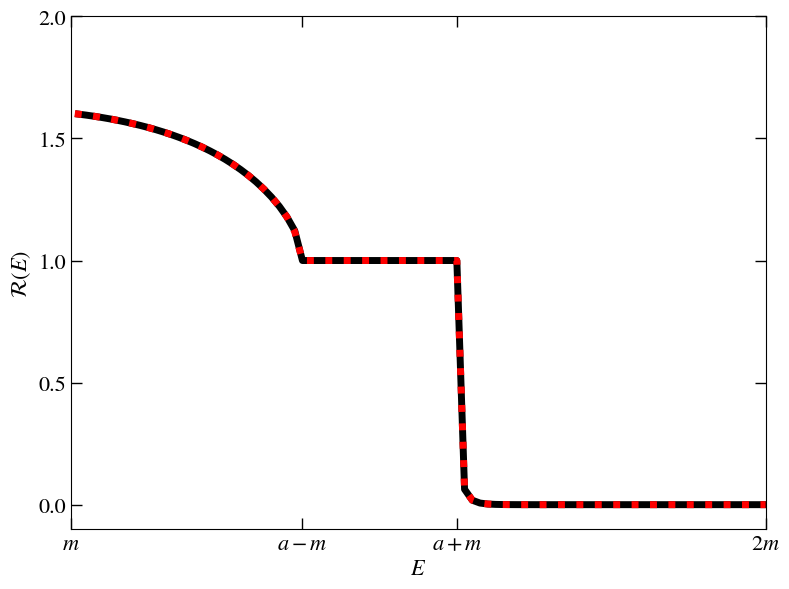

In [92]:
m = 1

plt.figure(figsize=(8, 6))

plt.plot(fullER, fullR, color="black", linestyle="-", linewidth=5,label=r"Analytic $\mathcal{R}(E)$")
plt.plot(E_mod2_tanh, R_mod2_tanh, color="r", linestyle="dotted",linewidth=5, label=r"$\mathcal{R}(E)$")


plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{R}(E)$", fontsize=16)
#plt.title(r"$a=5,\; b=2$", fontsize=14)

plt.xlim(m, 4*m)
plt.ylim(-0.1, 2.0)

# Custom ticks in units of m
a=5
plt.xticks(
    [m, a-m, a+m, 2*a],
    [r"$m$", r"$a-m$", r"$a+m$", r"$2m$"],
    fontsize=13
)
#xtick_labels = [r"$m$", r"$1.25m$", r"$1.5m$", r"$1.75m$", r"$2m$"]



plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 2.01, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)

# leg = plt.legend(
#     fontsize=13,
#     loc="best",
#     frameon=True,
#     fancybox=True,
#     framealpha=1,
#     edgecolor="black",
#     facecolor="white"
# )
# leg.get_frame().set_linewidth(2)

plt.tight_layout()
plt.savefig(path_data / "R(E)_tanh.png", dpi=300)
plt.show()

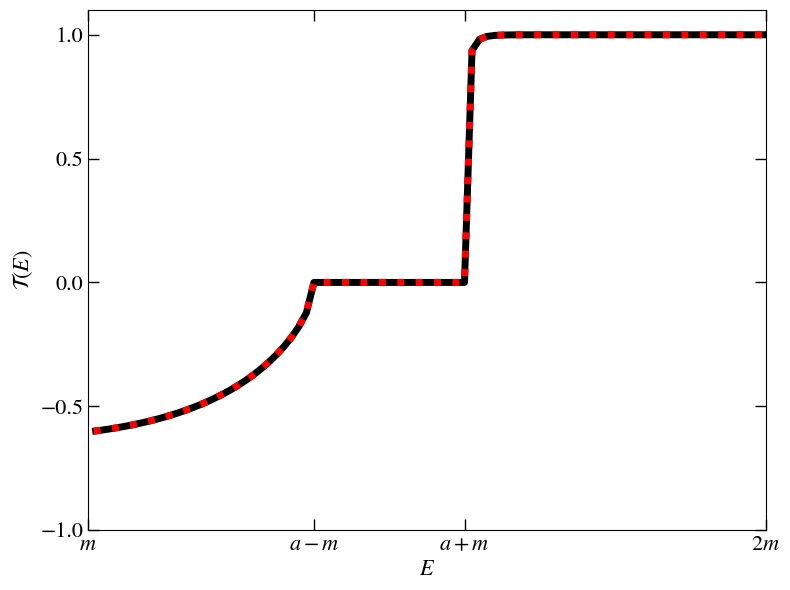

In [93]:
m = 1

plt.figure(figsize=(8, 6))

plt.plot(fullET, fullT, color="black", linestyle="-", linewidth=5,
         label=r"Analytic $\mathcal{T}(E)$")
plt.plot(E_mod2_tanh, T_mod2_tanh, color="red", linestyle="dotted", linewidth=5, label=r"$\mathcal{T}(E)$")


plt.xlabel(r"$E$", fontsize=16)
plt.ylabel(r"$\mathcal{T}(E)$", fontsize=16)
#plt.title(r"$a=5,\; b=2$", fontsize=14)

plt.xlim(m, 4*m)
plt.ylim(-1, 1.1)

# Custom ticks in units of m
a=5
plt.xticks(
    [m, a-m, a+m, 2*a],
    [r"$m$", r"$a-m$", r"$a+m$", r"$2m$"],
    fontsize=13
)
#xtick_labels = [r"$m$", r"$1.25m$", r"$1.5m$", r"$1.75m$", r"$2m$"]



plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(-1, 1.01, 0.5))
plt.tick_params(axis='both', which='both', direction='in', labelsize=16, top=True, right=True, length=8, width=1.0)


# leg = plt.legend(
#     fontsize=13,
#     loc=4,
#     frameon=True,
#     fancybox=True,
#     framealpha=1,
#     edgecolor="black",
#     facecolor="white"
# )
# leg.get_frame().set_linewidth(2)

plt.tight_layout()
plt.savefig(path_data / "T(E)_tanh.png", dpi=300)
plt.show()

We shif the energy from the left

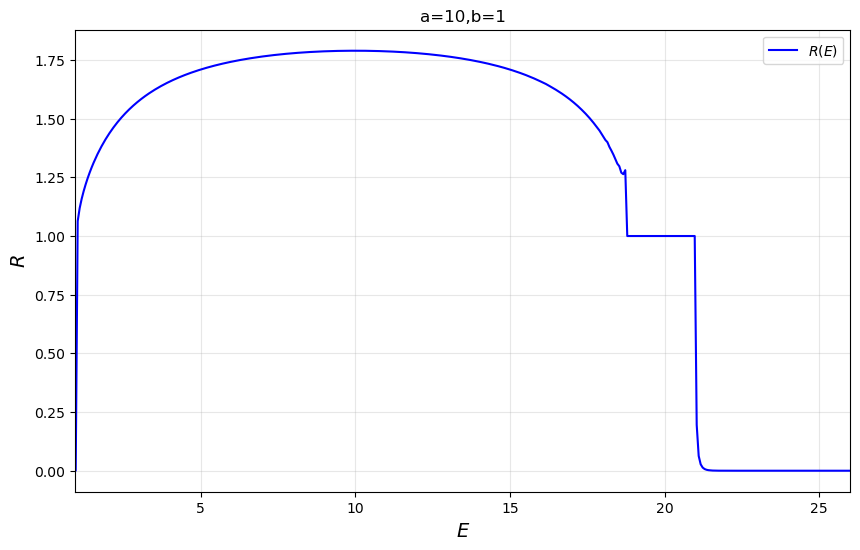

tanh: V_L=-25, V_R=-5, m=1
Raw superradiant window (step approx): (V_L+m, V_R-m)=(-24, -6)
Shifted window in Etilde: (m, (V_R-V_L)-m)=(1, 19)


In [44]:
# Shifted-energy plot: E_tilde = E - V_L (left asymptotic plateau)
Etilde_mod2 = E_mod2 - model2.VL

plt.figure(figsize=(10,6))
plt.plot(Etilde_mod2, R_mod2, color="b", label=r"$R(E)$")
#plt.plot(Etilde_mod2, T_mod2, color="r", label=r"$T(\tilde E)$")
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$R$", fontsize=14)
#plt.title(r"Shifted energy (tanh): $\tilde E = E - V_L$", fontsize=14)
plt.title("a=10,b=1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.95,26)
plt.savefig("tanh-R.png")
plt.show()

print(f"tanh: V_L={model2.VL:.6g}, V_R={model2.VR:.6g}, m={model2.m:.6g}")
print(f"Raw superradiant window (step approx): (V_L+m, V_R-m)=({model2.VL+model2.m:.6g}, {model2.VR-model2.m:.6g})")
print(f"Shifted window in Etilde: (m, (V_R-V_L)-m)=({model2.m:.6g}, {(model2.VR-model2.VL)-model2.m:.6g})")


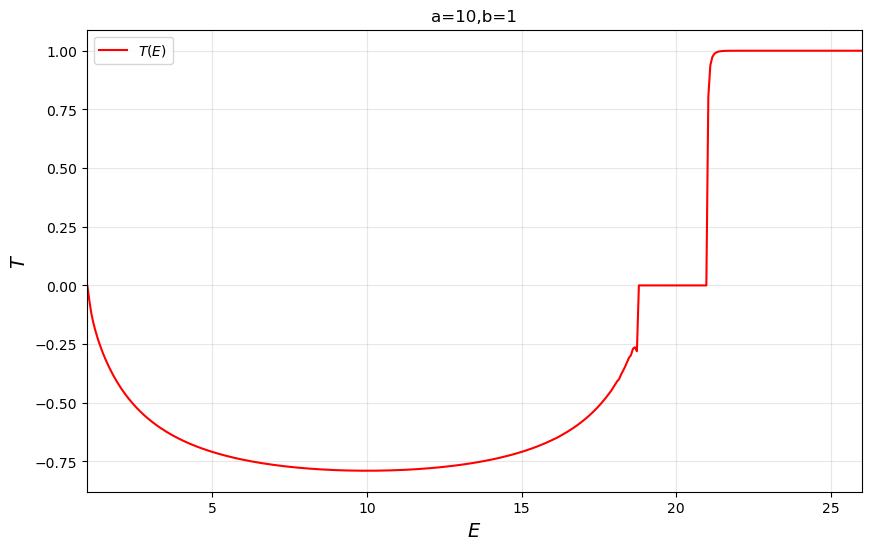

In [45]:

plt.figure(figsize=(10,6))
#plt.plot(Etilde_mod2, R_mod2, color="b", label=r"$R(E)$")
plt.plot(Etilde_mod2, T_mod2, color="r", label=r"$T(E)$")
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$T$", fontsize=14)
#plt.title(r"Shifted energy (tanh): $\tilde E = E - V_L$", fontsize=14)
plt.title("a=10,b=1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.95,26)
plt.savefig("tanh-T.png")
plt.show()


### Figure 2

In [13]:
V, VL, VR, label = kg.TanhPotential(a=5,b=50)
model2 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)

E_mod2,R_mod2,T_mod2 = model2.compute_RT_spectrum(E_min=0.1, E_max=10, nE=200)

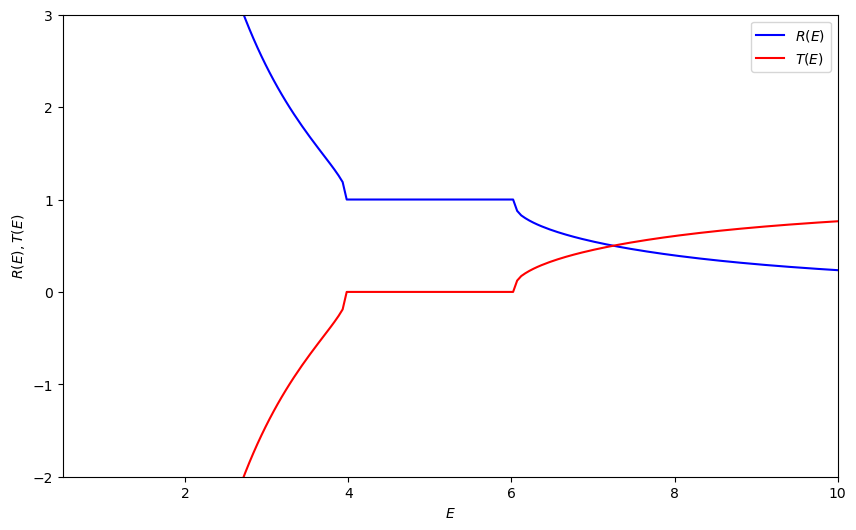

In [18]:
plt.figure(figsize=(10,6))
plt.plot(E_mod2, R_mod2, color="b",label=r"$R(E)$")
plt.plot(E_mod2, T_mod2, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.ylim(-2,3)
plt.xlim(0.5,10)
plt.legend()
plt.show()

### Woods-Saxon Potential 

In [ ]:
V, VL, VR, label = kg.woodsSaxonPotential(V0=4,a=10,b=2)
model3 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)
    
E_mod3,R_mod3,T_mod3 = model3.compute_RT_spectrum(E_min=0.1, E_max=10, nE=200)

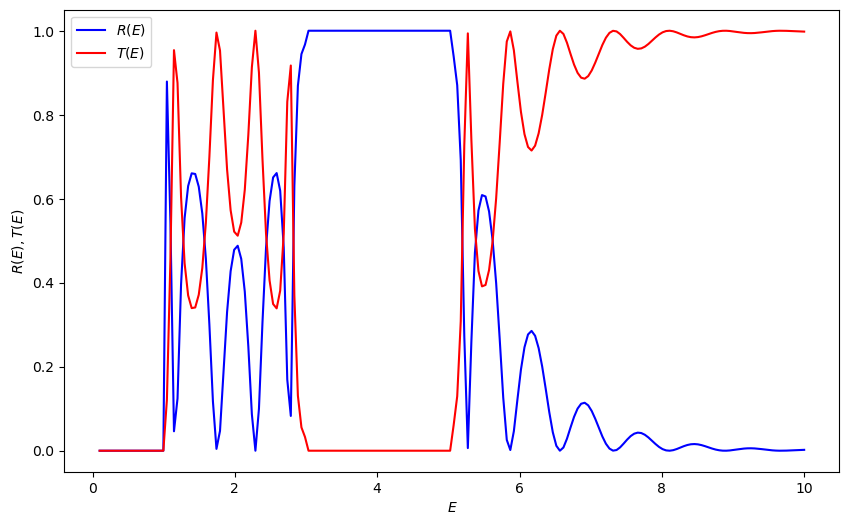

In [44]:
plt.figure(figsize=(10,6))
plt.plot(E_mod3, R_mod3, color="b",label=r"$R(E)$")
plt.plot(E_mod3, T_mod3, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.legend()
plt.show()

**Let's limit the x range for V0-m, where m is the mass (m=1)**

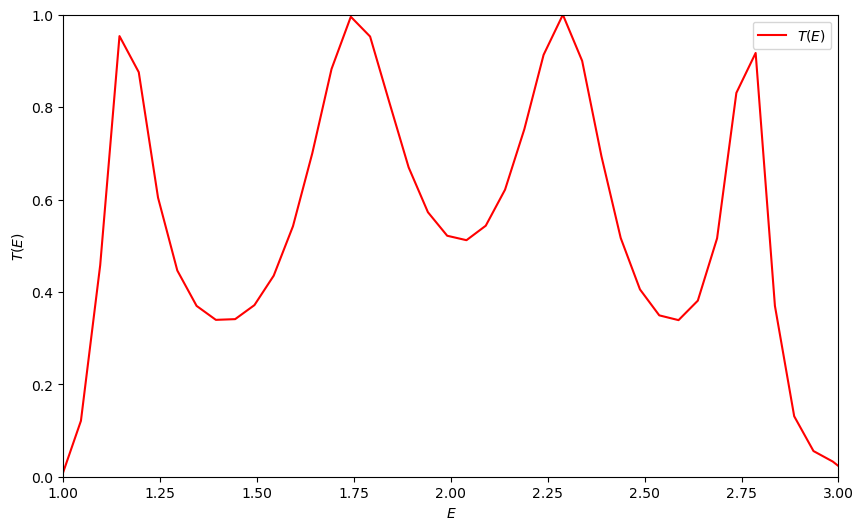

In [ ]:
plt.figure(figsize=(10,6))
#plt.plot(E_mod3, R_mod3, color="b",label=r"$R(E)$")
plt.plot(E_mod3, T_mod3, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
#plt.ylabel(r"$R(E), T(E)$")
plt.ylabel(r"$T(E)$")
plt.xlim(1,3)
plt.ylim(0,1)
plt.legend()
plt.show()

## Cups Potential

In [53]:
V, VL, VR, label = kg.cupsPotential(V0=4,a=1)
model4 = RiccatiModel(m=1,V=V,V_L=VL, V_R=VR, potential_label=label,XMIN=-10,XMAX=10,N_STEPS=6000)
    
E_mod4,R_mod4,T_mod4 = model4.compute_RT_spectrum(E_min=0.1, E_max=10, nE=500)

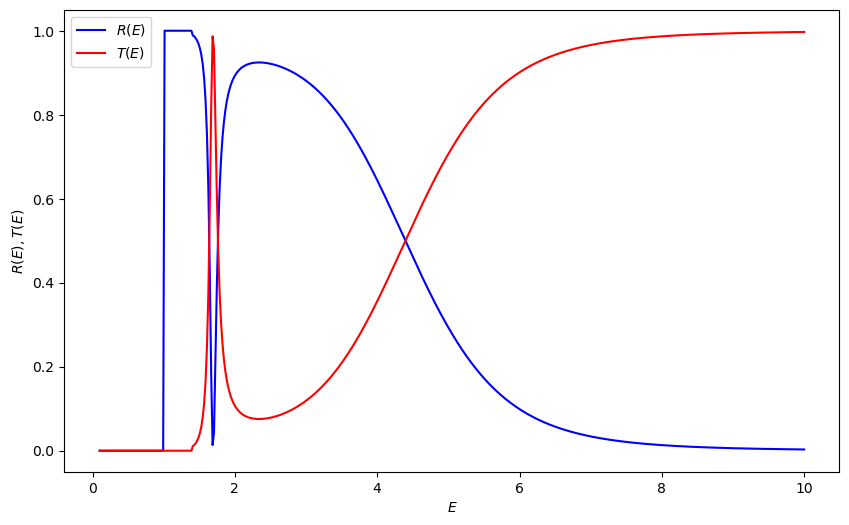

In [54]:
plt.figure(figsize=(10,6))
plt.plot(E_mod4, R_mod4, color="b",label=r"$R(E)$")
plt.plot(E_mod4, T_mod4, color="r",label=r"$T(E)$")
plt.xlabel(r"$E$")
plt.ylabel(r"$R(E), T(E)$")
plt.legend()
plt.show()